<a href="https://colab.research.google.com/github/Jaswanth431/DL-Assignment-1/blob/main/Assignment_1_Question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install wandb

In [18]:
from keras.datasets import fashion_mnist
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import wandb

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


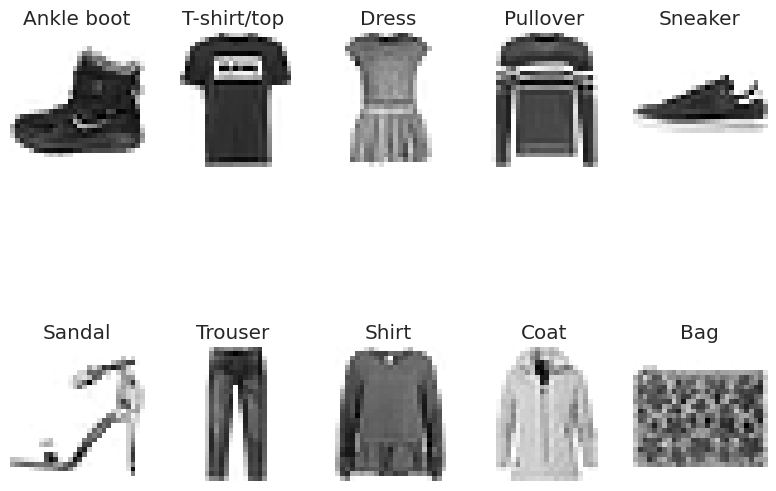

In [19]:
# Load data from data set
[(train_images, train_labels), (test_images, test_labels)] = fashion_mnist.load_data()
mySet = np.unique(train_labels)
myData = []
count = 10
for train_image, train_label in zip(train_images, train_labels):
    if train_label in mySet:
        myData.append(train_image)
        mySet = np.delete(mySet, np.where(mySet == train_label))
        count -= 1
    if count == 0:
        break

class_names = ['Ankle boot', 'T-shirt/top', 'Dress', 'Pullover', 'Sneaker', 'Sandal', 'Trouser', 'Shirt', 'Coat', 'Bag']

# Plot the selected images and upload a image to wandb
def plot_selected_images(images):
    fig, axes = plt.subplots(2, 5, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.set_title(class_names[i])
            ax.imshow(images[i], cmap=plt.cm.binary)
            ax.axis('off')
        else:
            ax.axis('off')
    plt.tight_layout()
    plt.savefig('class lables images.png')  # Save the plot as a PNG file

    # Initialize wandb run
    wandb.login()
    wandb.init(project='DL assignment 1')

    # Log the image file to wandb
    wandb.log({"class lable images": wandb.Image('class lables images.png')})
    plt.show()

plot_selected_images(myData)